# Usem com cuidado!
# Este notebook é legado, fiz quando ainda estava aprendendo Pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
igr_url = 'https://dadosabertos.ans.gov.br/FTP/PDA/IGR/IGR_versao_2023/IGR.csv'
petrobras = 422631
caixa = 312924
cassi = 346659
correios = 419133
dados = pd.read_csv(igr_url, sep=';' , encoding='utf-8')
dados['COMPETENCIA'] = pd.to_datetime(dados['COMPETENCIA'], format='%Y%m')
dados['QTD_RECLAMACOES_12M'] = dados.groupby('REGISTRO_ANS')['QTD_RECLAMACOES'].transform(lambda x: x[::-1].rolling(window=12, min_periods=1).sum()[::-1])
dados['IGR'] = dados['IGR'].str.replace(',', '.').astype(float)
dados_cassi = dados[dados['REGISTRO_ANS'] == cassi]
dados_cassi_recl = dados[dados['REGISTRO_ANS'] == cassi][['QTD_RECLAMACOES', 'COMPETENCIA','QTD_RECLAMACOES_12M', 'IGR']]
dados_correios = dados[dados['REGISTRO_ANS'] == correios]
dados_correios_recl = dados[dados['REGISTRO_ANS'] == correios][['QTD_RECLAMACOES', 'COMPETENCIA','QTD_RECLAMACOES_12M', 'IGR']]
dados_petrobras = dados[dados['REGISTRO_ANS'] == petrobras]
dados_petrobras_recl = dados[dados['REGISTRO_ANS'] == petrobras][['QTD_RECLAMACOES', 'COMPETENCIA','QTD_RECLAMACOES_12M', 'IGR']]
dados_SC = dados[dados['REGISTRO_ANS'] == caixa]
dados_SC_recl = dados[dados['REGISTRO_ANS'] == caixa][['QTD_RECLAMACOES', 'COMPETENCIA','QTD_RECLAMACOES_12M', 'IGR']]

dados_SC_recl_2024 = dados_SC_recl[dados_SC_recl['COMPETENCIA'].dt.year == 2024]
dados_SC_recl_2025 = dados_SC_recl[dados_SC_recl['COMPETENCIA'].dt.year == 2025]

dados_SC_recl_2024['QTD_RECLAMACOES'].sum(), dados_SC_recl_2025['QTD_RECLAMACOES'].sum()

(np.int64(1237), np.int64(2778))

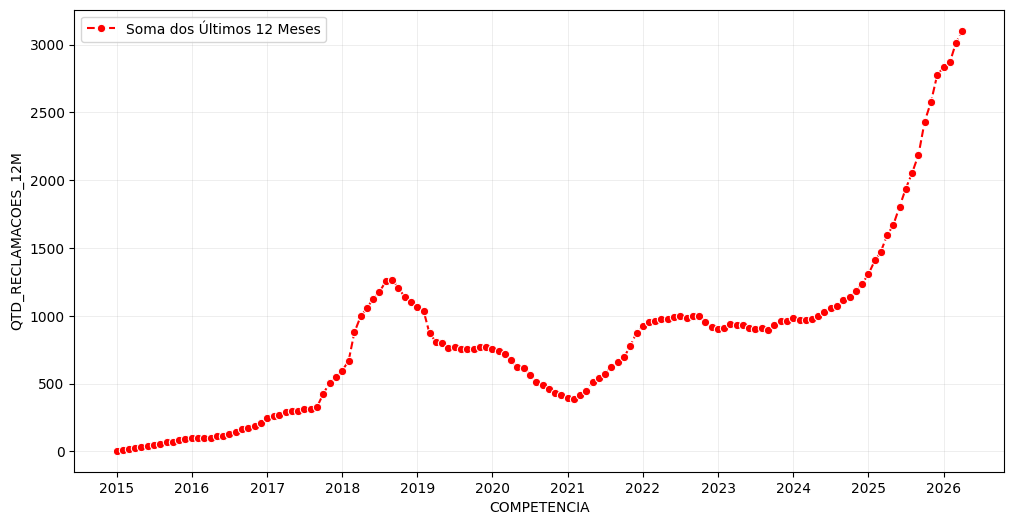

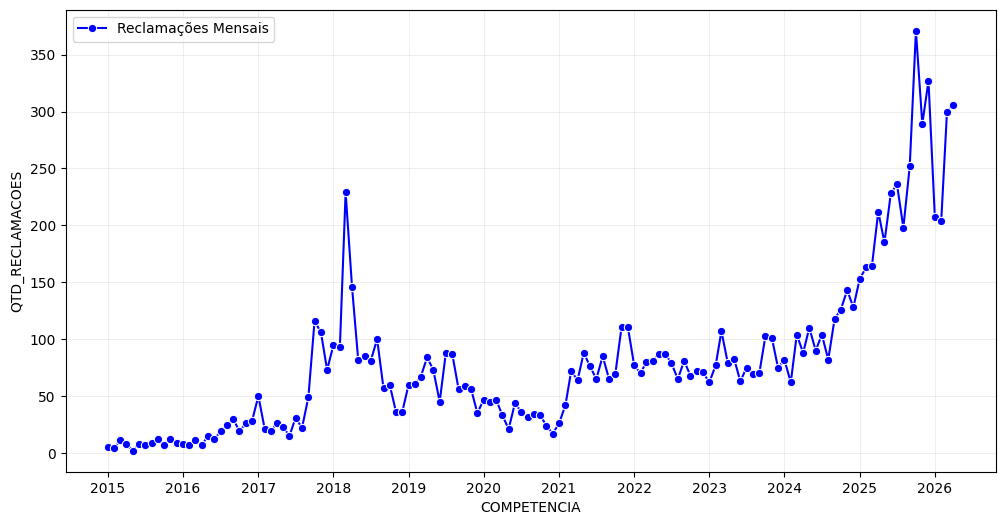

In [4]:
a, x = plt.subplots(figsize=(12,6))
#sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações Mensais')
sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES_12M', marker='o', color='red', label='Soma dos Últimos 12 Meses', linestyle='--')
# Adicionar linhas de grade
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

from matplotlib.dates import YearLocator, DateFormatter
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))

plt.legend()
plt.show()

a, x = plt.subplots(figsize=(12,6))
sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações Mensais')
#sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES_12M', marker='o', color='red', label='Soma dos Últimos 12 Meses', linestyle='--')

plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

from matplotlib.dates import YearLocator, DateFormatter
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))

plt.legend()
plt.show()

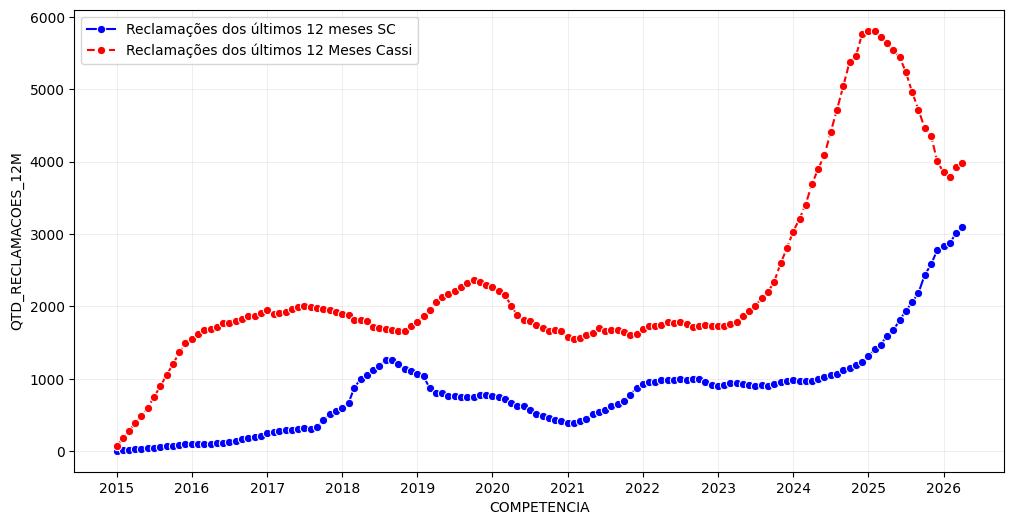

In [5]:
a, x = plt.subplots(figsize=(12,6))
sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES_12M', marker='o', color='blue', label='Reclamações dos últimos 12 meses SC')
sns.lineplot(data=dados_cassi_recl, x='COMPETENCIA', y='QTD_RECLAMACOES_12M', marker='o', color='red', label='Reclamações dos últimos 12 Meses Cassi', linestyle='--')
# Adicionar linhas de grade
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Ajustar espaçamento do eixo x para 1 ano
from matplotlib.dates import YearLocator, DateFormatter
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))

plt.legend()
plt.show()

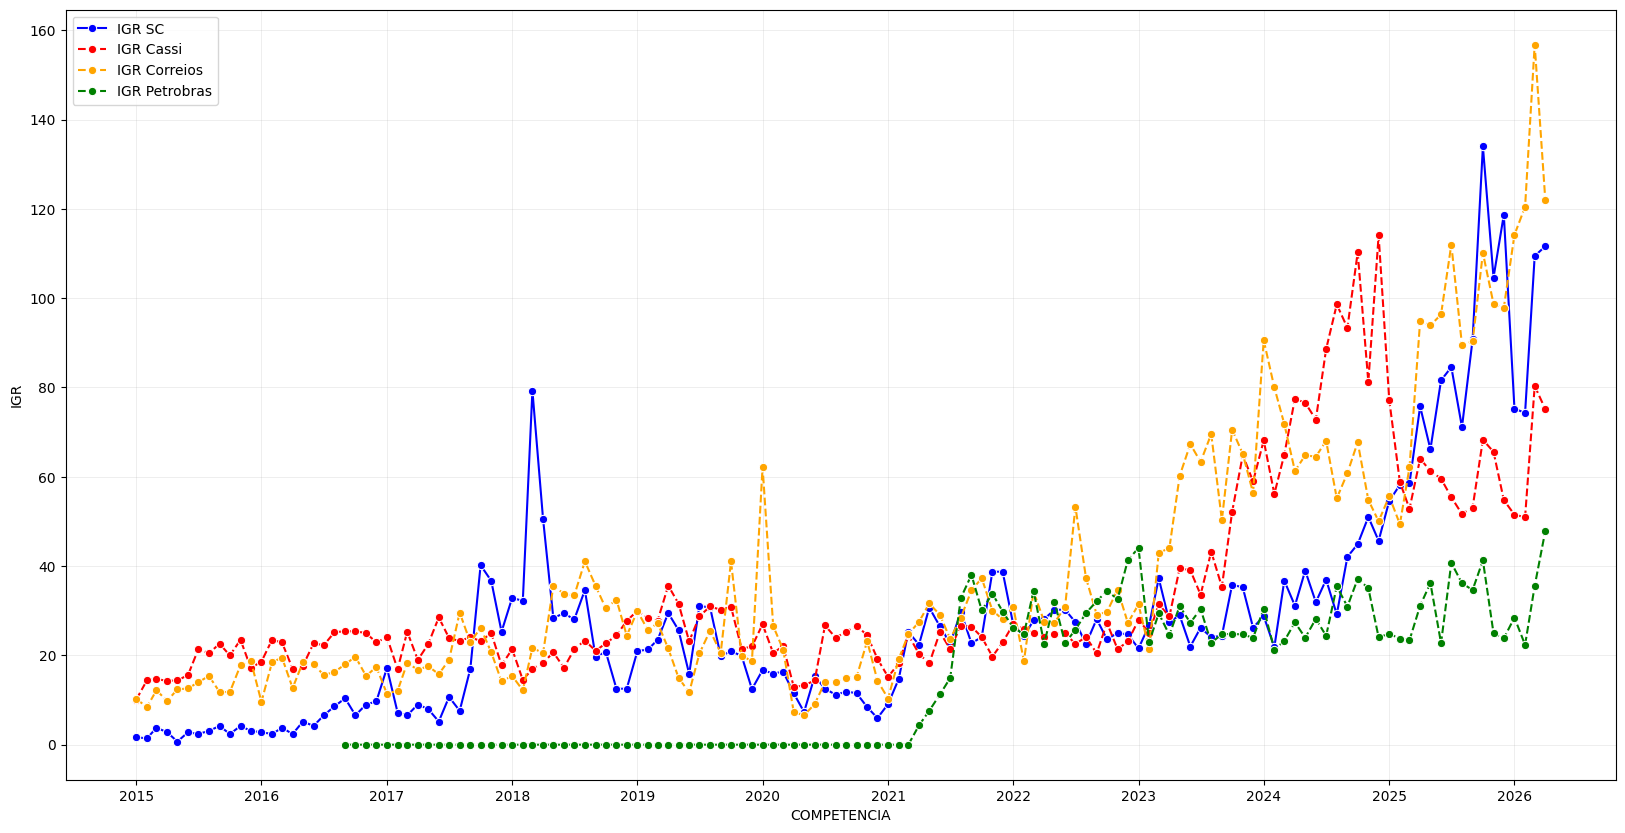

In [6]:
a, x = plt.subplots(figsize=(20,10))
sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='IGR', marker='o', color='blue', label='IGR SC')
sns.lineplot(data=dados_cassi_recl, x='COMPETENCIA', y='IGR', marker='o', color='red', label='IGR Cassi', linestyle='--')
sns.lineplot(data=dados_correios_recl, x='COMPETENCIA', y='IGR', marker='o', color='orange', label='IGR Correios', linestyle='--')
sns.lineplot(data=dados_petrobras_recl, x='COMPETENCIA', y='IGR', marker='o', color='green', label='IGR Petrobras', linestyle='--')

plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

from matplotlib.dates import YearLocator, DateFormatter
x.xaxis.set_major_locator(YearLocator(1))
x.xaxis.set_major_formatter(DateFormatter('%Y'))


plt.legend()
plt.show()


In [7]:
dados_SC

,REGISTRO_ANS,RAZAO_SOCIAL,COBERTURA,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,PORTE_OPERADORA,COMPETENCIA,COMPETENCIA_BENEFICIARIO,DT_ATUALIZACAO,QTD_RECLAMACOES_12M
101,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,111.63,306,274114,Grande,2026-04-01,202603,2026-05-07,3103.0
1078,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,109.44,300,274114,Grande,2026-03-01,202603,2026-05-07,3009.0
2055,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,74.30,204,274570,Grande,2026-02-01,202602,2026-05-07,2873.0
3033,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,75.27,207,274998,Grande,2026-01-01,202601,2026-05-07,2832.0
4010,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,118.68,327,275536,Grande,2025-12-01,202512,2026-05-07,2778.0
...,...,...,...,...,...,...,...,...,...,...,...
144010,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,0.70,2,288878,Grande,2015-05-01,201505,NaN,30.0
145333,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,2.80,8,288064,Grande,2015-04-01,201504,NaN,28.0
146660,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,3.80,11,287805,Grande,2015-03-01,201503,NaN,20.0
147989,312924,CAIXA ECONÔMICA FEDERAL,Assistência médica,1.40,4,287417,Grande,2015-02-01,201502,NaN,9.0


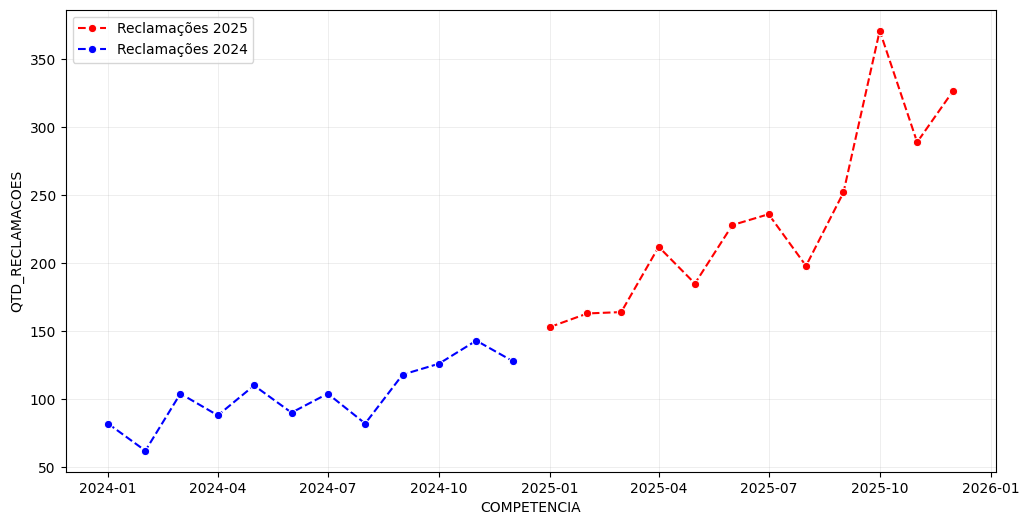

In [8]:
a, x = plt.subplots(figsize=(12,6))
#sns.lineplot(data=dados_SC_recl, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações Mensais')
sns.lineplot(data=dados_SC_recl_2025, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='red', label='Reclamações 2025', linestyle='--')
sns.lineplot(data=dados_SC_recl_2024, x='COMPETENCIA', y='QTD_RECLAMACOES', marker='o', color='blue', label='Reclamações 2024', linestyle='--')

# Adicionar linhas de grade
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.legend()
plt.show()


In [9]:
dados.fillna()
dados.mean()
pd.to_numeric()

TypeError: NDFrame.fillna() missing 1 required positional argument: 'value'